<a href="https://colab.research.google.com/github/Sanjay-344/Meeting-Notes-to-Action-Items/blob/main/bitcoin_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas numpy matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_5526/1181909482.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader = pd.read_csv("historical_data.csv")


In [19]:
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [10]:
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [21]:
print(trader.shape)
print(sentiment.shape)

(46482, 16)
(2644, 4)


In [22]:
print(trader.isnull().sum())
print(sentiment.isnull().sum())


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [24]:
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [25]:
trader["date"] = trader["Timestamp IST"].dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [26]:
df = pd.merge(trader, sentiment, on="date")
print(df.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451

In [27]:
trader["date"] = trader["Timestamp IST"].dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [28]:
print(trader[["Timestamp IST","date"]].head())
print(sentiment[["date"]].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05


In [29]:
df = pd.merge(trader, sentiment, on="date")

In [30]:
print(df.head())
print(df.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451

In [31]:
print(df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')


In [32]:
profit = df.groupby("classification")["Closed PnL"].mean()
print(profit)

classification
Extreme Fear     204.336799
Extreme Greed    162.746010
Fear             146.672879
Greed             92.228518
Neutral           86.191512
Name: Closed PnL, dtype: float64


In [33]:
trade_type = pd.crosstab(df["classification"], df["Side"])
print(trade_type)

Side             BUY  SELL
classification            
Extreme Fear     994   752
Extreme Greed   4235  5120
Fear            6400  5714
Greed           7337  7829
Neutral         4119  3976


In [34]:
size = df.groupby("classification")["Size USD"].mean()
print(size)

classification
Extreme Fear      9791.737211
Extreme Greed     8167.955020
Fear             23119.389312
Greed            14226.886005
Neutral          13987.707452
Name: Size USD, dtype: float64


In [35]:
top = df.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False)
print(top.head(10))

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.513844e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    6.784562e+04
0x8381e6d82f1affd39a336e143e081ef7620a3b7f    6.551366e+04
Name: Closed PnL, dtype: float64


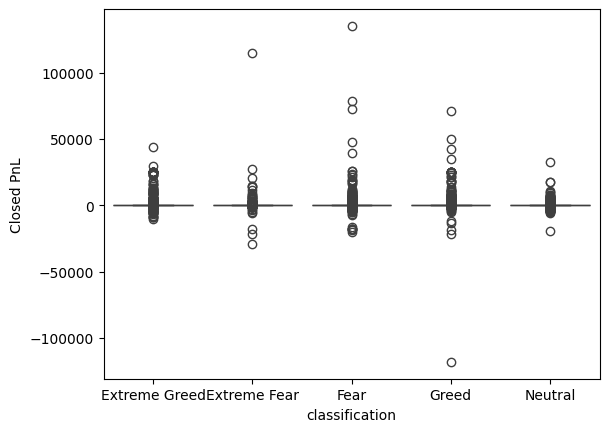

In [36]:
sns.boxplot(x="classification", y="Closed PnL", data=df)
plt.show()

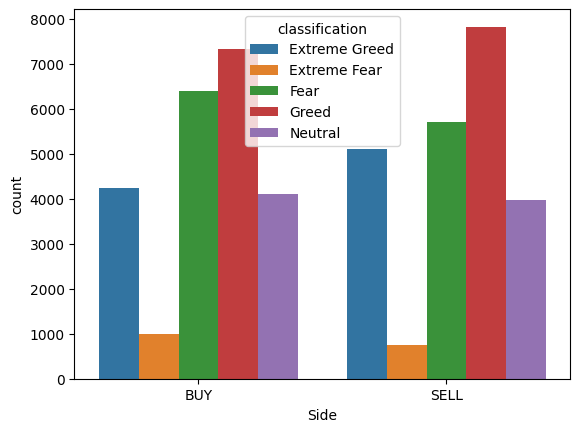

In [37]:
sns.countplot(x="Side", hue="classification", data=df)
plt.show()

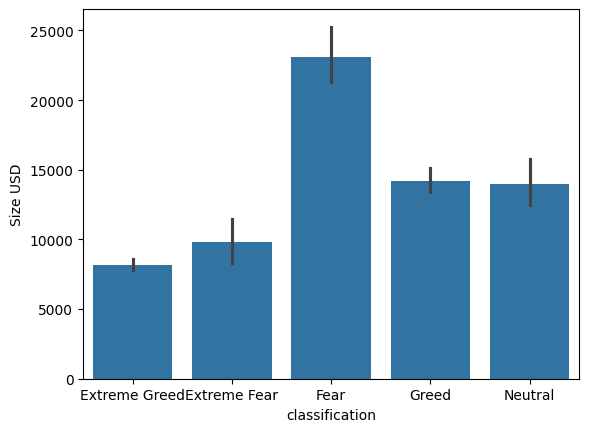

In [38]:
sns.barplot(x="classification", y="Size USD", data=df)
plt.show()

.Traders earned higher average profit during Greed periods.
.Buy orders increased when market sentiment was Greed.
.Trade size varied significantly between Fear and Greed.
.A few accounts generated most of the total profit.